# Softmax Regression


In [8]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, log_loss
import sys
import re
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [9]:
sys.path.append('/content/drive/My Drive/csc311-food-prediction')


from cleaning_Q7_Q8 import process_data
from cleaning_Q1_Q2 import parse_q2_response
from cleanDataQ3Q6 import map_drink
from cleanQ4Q5 import create_movie_features

ModuleNotFoundError: No module named 'cleaning_Q7_Q8'

In [45]:
data = pd.read_csv("cleaned_data_combined_modified.csv")

def load_data(file_path):
    return pd.read_csv(file_path)


In [46]:
def process_q1_data(df):
    q1_col = [col for col in df.columns if 'Q1' in col][0]

    def extract_numeric(value):
        if pd.isna(value):
            return np.nan
        if isinstance(value, (int, float)):
            return float(value)
        matches = re.findall(r'\d+', str(value))
        if matches:
            return float(matches[0])
        return np.nan

    q1_values = df[q1_col].apply(extract_numeric)

    q1_features = np.array(q1_values).reshape(-1, 1)

    median_value = np.nanmedian(q1_features)
    q1_features = np.nan_to_num(q1_features, nan=median_value)

    return q1_features, "complexity_rating"

In [47]:
def process_q2_data_fix(df):
    q2_col = [col for col in df.columns if 'Q2' in col][0]

    word_bank_by_label = {
        'Pizza': {'cheese', 'tomato', 'dough', 'pepperoni', 'sauce', 'basil', 'water', 'oil', 'meat', 'olives'},
        'Shawarma': {'meat', 'pita', 'garlic', 'tahini', 'salad', 'onion', 'chicken', 'sauce', 'fries', 'rice'},
        'Sushi': {'rice', 'fish', 'seaweed', 'soy', 'wasabi', 'ginger', 'salmon', 'avocado'}
    }

    def clean_q2_row(row):
        bank = word_bank_by_label.get(row["Label"], None)
        return parse_q2_response(row[q2_col], word_bank=bank)

    q2_cleaned = df.apply(clean_q2_row, axis=1)

    q2_features = np.array(q2_cleaned).reshape(-1, 1)

    median_value = np.nanmedian(q2_features)
    q2_features = np.nan_to_num(q2_features, nan=median_value)

    return q2_features, "ingredient_count"

In [48]:
def process_q4_data_fix(df):
    q4_col = [col for col in df.columns if 'Q4' in col][0]

    def extract_price(value):
        if pd.isna(value):
            return np.nan
        if isinstance(value, (int, float)):
            return float(value)
        matches = re.findall(r'\d+(?:\.\d+)?', str(value))
        if matches:
            return float(max(matches, key=float))
        return np.nan

    q4_values = df[q4_col].apply(extract_price)

    q4_features = np.array(q4_values).reshape(-1, 1)

    median_value = np.nanmedian(q4_features)
    q4_features = np.nan_to_num(q4_features, nan=median_value)
    return q4_features, "price_expectation"

In [49]:
def process_q3q6_data(df):
    """
    Process Q3 (meal occasion) and Q6 (drink pairing) into bag of words features.

    Args:
        df: DataFrame containing the survey data

    Returns:
        q3_features: numpy array of shape (n_samples, n_q3_words)
        q6_features: numpy array of shape (n_samples, n_q6_words)
        q3_word_to_idx: dictionary mapping Q3 words to column indices
        q6_word_to_idx: dictionary mapping Q6 drinks to column indices
    """
    q3_col = [col for col in df.columns if 'Q3' in col][0]
    df.loc[:, q3_col] = df[q3_col].fillna('').str.lower().str.strip()

    q6_col = [col for col in df.columns if 'Q6' in col][0]
    df.loc[:, q6_col] = df[q6_col].fillna('').str.lower().str.strip()

    df.loc[:, q6_col] = df[q6_col].apply(map_drink)

    all_q3_words = set()
    for response in df[q3_col].dropna():
        words = response.split(',')
        all_q3_words.update(word.strip() for word in words if word.strip())

    q3_word_to_idx = {word: idx for idx, word in enumerate(sorted(all_q3_words))}

    all_q6_words = set()
    for response in df[q6_col].dropna():
        words = response.split(',')
        all_q6_words.update(word.strip() for word in words if word.strip())

    q6_word_to_idx = {word: idx for idx, word in enumerate(sorted(all_q6_words))}

    n_samples = len(df)
    n_q3_words = len(q3_word_to_idx)
    n_q6_words = len(q6_word_to_idx)

    q3_features = np.zeros((n_samples, n_q3_words))
    q6_features = np.zeros((n_samples, n_q6_words))

    for i, response in enumerate(df[q3_col].fillna('')):
        if response:
            words = response.split(',')
            for word in words:
                word = word.strip()
                if word and word in q3_word_to_idx:
                    q3_features[i, q3_word_to_idx[word]] = 1

    for i, response in enumerate(df[q6_col].fillna('')):
        if response:
            words = response.split(',')
            for word in words:
                word = word.strip()
                if word and word in q6_word_to_idx:
                    q6_features[i, q6_word_to_idx[word]] = 1

    return q3_features, q6_features, q3_word_to_idx, q6_word_to_idx

In [70]:
full_data_path = "cleaned_data_combined.csv"
df = pd.read_csv(full_data_path)
print("Full data shape:", df.shape)

test_size = 723
df_test = df.iloc[:test_size]
df_train = df.iloc[test_size:]

print(f"Train size: {len(df_train)}  Test size: {len(df_test)}")

train_features_list = []
test_features_list = []
feature_names = []

q1_train_features, q1_name = process_q1_data(df_train)
q1_test_features, _ = process_q1_data(df_test)
train_features_list.append(q1_train_features)
test_features_list.append(q1_test_features)
feature_names.append(q1_name)

q2_train_features, q2_name = process_q2_data_fix(df_train)
q2_test_features, _ = process_q2_data_fix(df_test)
train_features_list.append(q2_train_features)
test_features_list.append(q2_test_features)
feature_names.append(q2_name)

q3_train_features, q6_train_features, q3_word_to_idx, q6_word_to_idx = process_q3q6_data(df_train)
q3_test_features = np.zeros((len(df_test), len(q3_word_to_idx)))
q6_test_features = np.zeros((len(df_test), len(q6_word_to_idx)))

q3_col = [col for col in df_test.columns if 'Q3' in col][0]
q6_col = [col for col in df_test.columns if 'Q6' in col][0]

for i, response in enumerate(df_test[q3_col].fillna('')):
    if response:
        for word in response.split(','):
            word = word.strip().lower()
            if word in q3_word_to_idx:
                q3_test_features[i, q3_word_to_idx[word]] = 1

for i, response in enumerate(df_test[q6_col].fillna('')):
    if response:
        for word in response.split(','):
            word = word.strip().lower()
            if word in q6_word_to_idx:
                q6_test_features[i, q6_word_to_idx[word]] = 1

train_features_list.append(q3_train_features)
train_features_list.append(q6_train_features)
test_features_list.append(q3_test_features)
test_features_list.append(q6_test_features)
feature_names.extend([f'q3_{word}' for word in sorted(q3_word_to_idx.keys())])
feature_names.extend([f'q6_{word}' for word in sorted(q6_word_to_idx.keys())])

q4_train_features, q4_name = process_q4_data_fix(df_train)
q4_test_features, _ = process_q4_data_fix(df_test)
train_features_list.append(q4_train_features)
test_features_list.append(q4_test_features)
feature_names.append(q4_name)

q5_train_features, q5_word_to_idx = create_movie_features(df_train)
q5_test_features = np.zeros((len(df_test), len(q5_word_to_idx)))
q5_col = [col for col in df_test.columns if 'Q5' in col][0]
for i, response in enumerate(df_test[q5_col].fillna('')):
    if response:
        for movie in response.split(','):
            movie = movie.strip().lower()
            if movie in q5_word_to_idx:
                q5_test_features[i, q5_word_to_idx[movie]] = 1
train_features_list.append(q5_train_features)
test_features_list.append(q5_test_features)
feature_names.extend([f'q5_{movie}' for movie in sorted(q5_word_to_idx.keys())])

q7_train_features, q8_train_features, q7_word_to_idx, q8_category_to_idx = process_data(df_train)
q7_test_features, q8_test_features, _, _ = process_data(df_test)
train_features_list.append(q7_train_features)
train_features_list.append(q8_train_features)
test_features_list.append(q7_test_features)
test_features_list.append(q8_test_features)
feature_names.extend([f'q7_{word}' for word in sorted(q7_word_to_idx.keys())])
feature_names.extend([f'q8_{cat}' for cat in sorted(q8_category_to_idx.keys())])

X_train = np.hstack(train_features_list)
X_test = np.hstack(test_features_list)

y_train = df_train['Label'].values
y_test = df_test['Label'].values

softmax_model = LogisticRegression(solver="lbfgs", max_iter=1000)
softmax_model.fit(X_train, y_train)

y_train_pred = softmax_model.predict(X_train)
y_test_pred = softmax_model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
report = classification_report(y_test, y_test_pred)

train_probs = softmax_model.predict_proba(X_train)
test_probs = softmax_model.predict_proba(X_test)
train_loss = log_loss(y_train, train_probs)
test_loss = log_loss(y_test, test_probs)


# Define the parameter grid
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(softmax_model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_C = grid_search.best_params_['C']
print("Best C value:", best_C)


best_model = grid_search.best_estimator_

y_test_pred = best_model.predict(X_test)
taccuracy = accuracy_score(y_test, y_test_pred)


print("Combined feature matrix shape:", X_train.shape)
print("\nTraining Accuracy: {:.4f}".format(train_accuracy))
print("Test Accuracy: {:.4f}".format(test_accuracy))
print("\nTraining Log Loss: {:.4f}".format(train_loss))
print("Test Log Loss: {:.4f}".format(test_loss))
print("\nClassification Report:\n", report)
print("TA after tuning", taccuracy)

Full data shape: (1644, 10)
Train size: 921  Test size: 723
Combined feature matrix shape: (921, 622)

Training Accuracy: 0.9392
Test Accuracy: 0.8741

Training Log Loss: 0.2230
Test Log Loss: 0.3521

Classification Report:
               precision    recall  f1-score   support

       Pizza       0.86      0.87      0.86       241
    Shawarma       0.91      0.88      0.89       241
       Sushi       0.85      0.88      0.87       241

    accuracy                           0.87       723
   macro avg       0.87      0.87      0.87       723
weighted avg       0.87      0.87      0.87       723


# Analysis of Softmax Regression

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

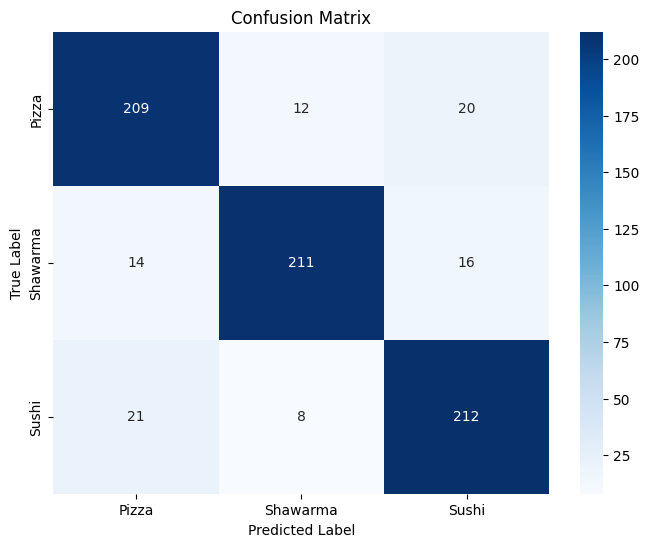

In [74]:
cm = confusion_matrix(y_test, y_test_pred, labels=softmax_model.classes_)

# Plot the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=softmax_model.classes_, yticklabels=softmax_model.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

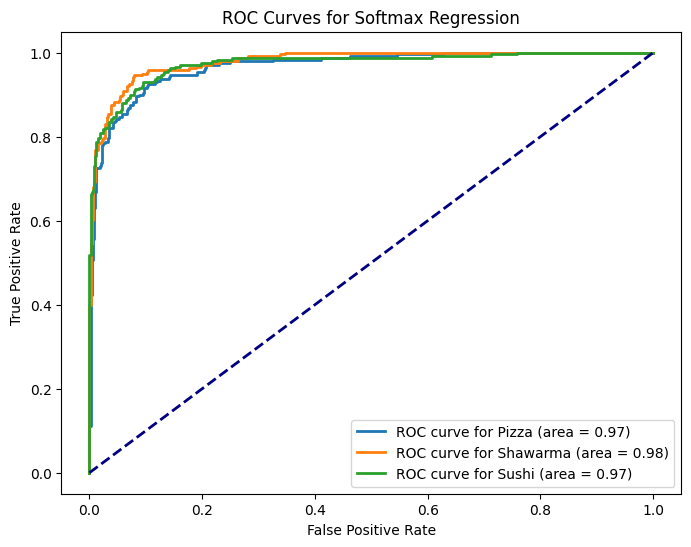

In [76]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = softmax_model.classes_
y_test_bin = label_binarize(y_test, classes=classes)
y_score = softmax_model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'ROC curve for {classes[i]} (area = {roc_auc[i]:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Softmax Regression")
plt.legend(loc="lower right")
plt.show()


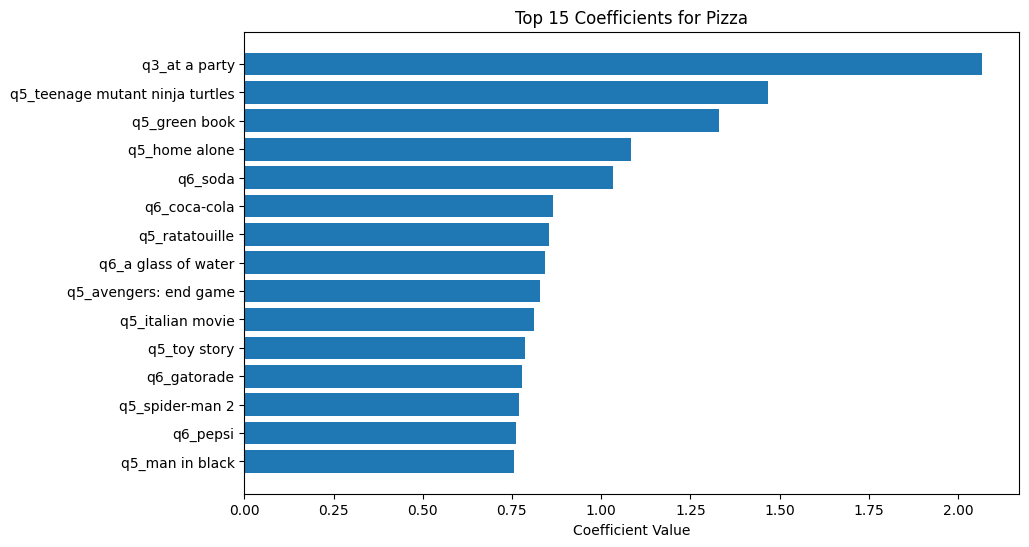

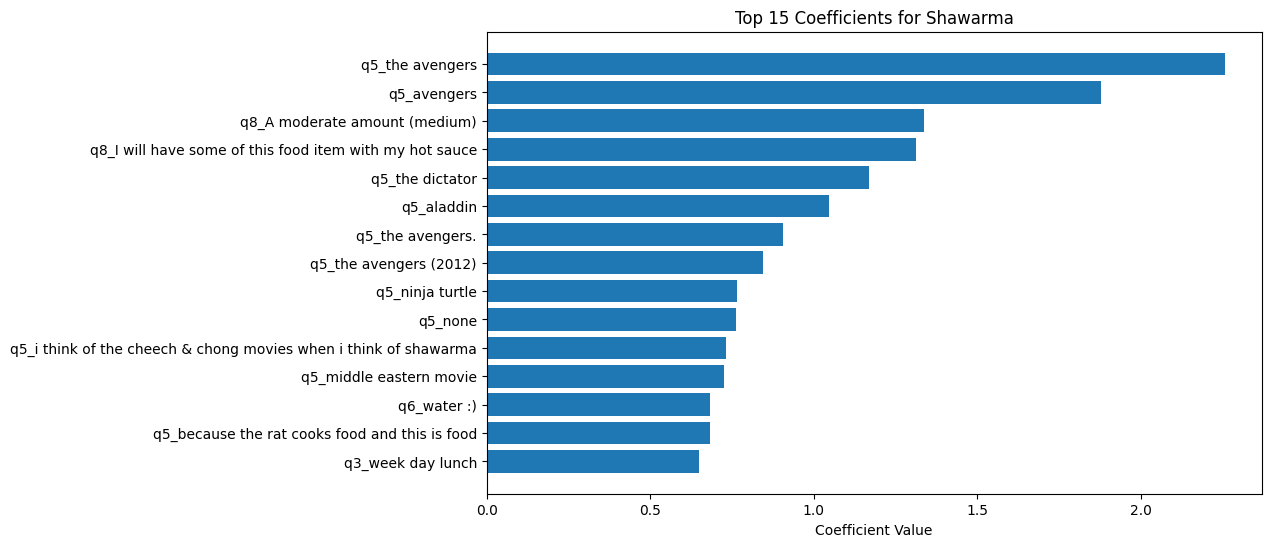

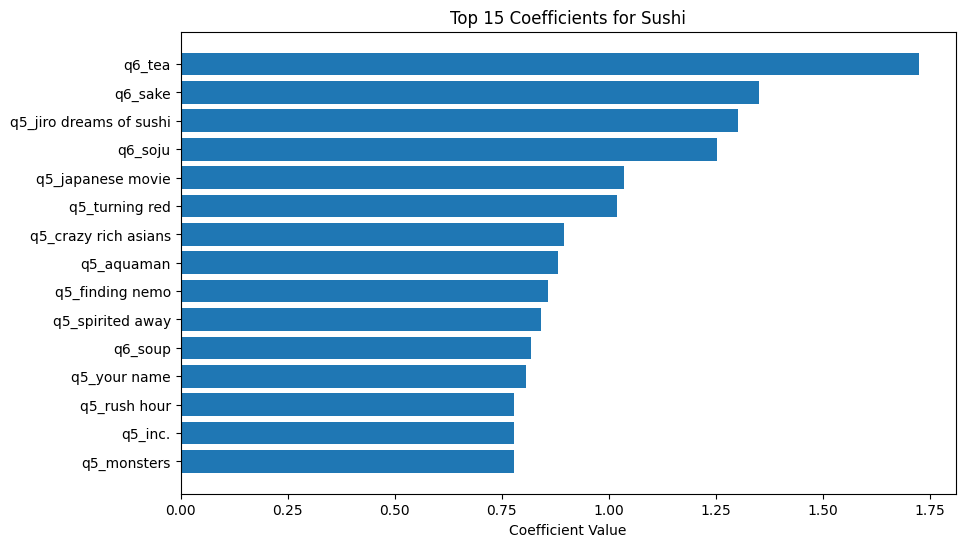

In [79]:
for i, label in enumerate(softmax_model.classes_):
    coef = softmax_model.coef_[i]
    indices = np.argsort(coef)[-15:]
    plt.figure(figsize=(10, 6))
    plt.barh(range(15), coef[indices], align='center')
    plt.yticks(range(15), [feature_names[idx] for idx in indices])
    plt.xlabel("Coefficient Value")
    plt.title(f"Top 15 Coefficients for {label}")
    plt.show()
